In [4]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import os
import math

#plt.rcParams['text.usetex'] = True
#rfont = {'fontname':'Times New Roman'}
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# Spin matrix
S0 = qt.qeye(3)                                                # {1, 0, -1}
Sx, Sy, Sz = qt.jmat(1)                                        # {1, 0, -1}
sigma0 = qt.qeye(2)                                            # {Ex, Ey}
sigmax, sigmay, sigmaz = qt.sigmax(), qt.sigmay(), qt.sigmaz() # {Ex, Ey}

# Physics constant
h             = 6.626e-34        # J/Hz
muB           = 9.274e-24 / h    # Hz/T
Des_para      = 1.42e9           # Hz       # [Doherty 2013], 1.44e9[Bassett 2014] 
Des_perp      = 1.55e9/2         # Hz       # [Doherty 2013], 1.541e9[Bassett 2014] 
lambdaes_para = 5.3e9            # Hz       # [Doherty 2013], 5.33e9[Bassett 2014]
lambdaes_perp = 0.2e9/np.sqrt(2) # Hz       # [Doherty 2013]
des_para      = 6e3              # Hz/(V/m) # [Doherty 2013]?
des_perp      = 6e3              # Hz/(V/m) # [Doherty 2013]?
les_para      = 0.1              # 1        # [Doherty 2013], 0.05[Bassett 2014] at 1.5K
ges_para      = 2.01             # 1        # [Doherty 2013], 2.15[Bassett 2014]
ges_perp      = 2.01             # 1        # [Doherty 2013]

In [2]:
# bare Hamiltonian
H_es = Des_para * qt.tensor(sigma0, Sz**2 - 2/3 * S0) \
       - lambdaes_para * qt.tensor(sigmay, Sz) \
       + Des_perp * (qt.tensor(sigmaz, Sy**2 - Sx**2) - qt.tensor(sigmax, Sy * Sx + Sx * Sy)) \
       + lambdaes_perp * (qt.tensor(sigmaz, Sx * Sz + Sz * Sx) - qt.tensor(sigmax, Sy * Sz + Sz * Sy))

# Interaction Hamiltonian
def V_es(E, B, delta):
    return des_para * (E[2] + delta[2]) * qt.tensor(sigma0, S0) \
           + des_perp * (E[0] + delta[0]) * qt.tensor(sigmaz, S0) \
           - des_perp * (E[1] + delta[1]) * qt.tensor(sigmax, S0) \
           + muB * (les_para * qt.tensor(sigmay, S0) + ges_para * qt.tensor(sigma0, Sz)) * B[2] \
           + muB * ges_perp * qt.tensor(sigma0, Sx * B[0] + Sy * B[1])


### stream line

1. Decpmpose eigenstates besed on spin basis
2. Extracting the amplitude coresponded to spin basis, resoectuvily
3. Define condition value ,Xi, which can reflect how spin basis are mixed , 
4. plot the normalized Xi  , sweeping magneticfield(para) and strain(perp)

In [11]:
# Decompostion of eigenstates based on spin basis
def Decomposition(H_tot):
    ee, ev = H_tot.eigenstates()
    ev_amp = [abs(evi.full()) for evi in ev][::-1]

    return ev_amp


# condition value
def Xi(List,i,j):
    a_i = List[i-1]
    a_j = List[j-1]

    #return ( abs( abs(a_i)-abs(a_j) ) )/(abs(a_i) + abs(a_j) )
    return (abs( abs(a_i)-abs(a_j)))/(1)

'|A_1>'

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_30520\1131601336.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = 1e9 / diff   # Normalized unit: 1/nanosecond or similar


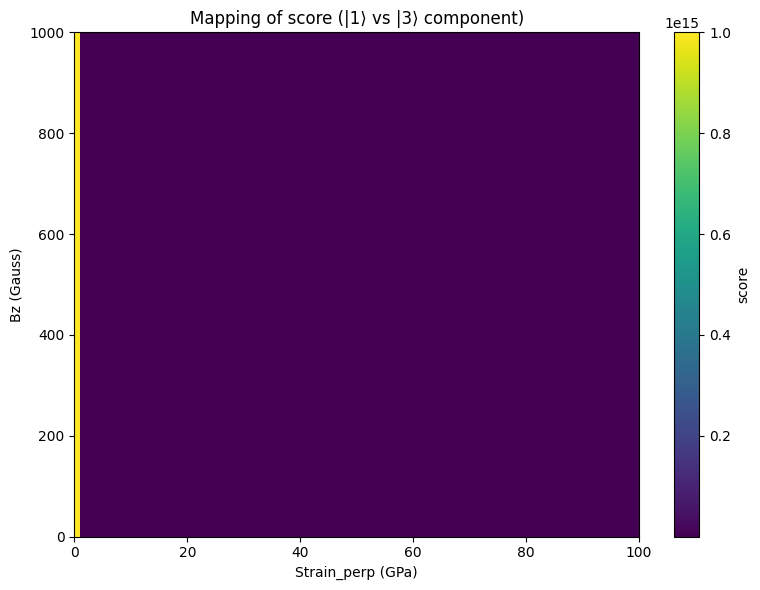

In [4]:
# Meshgrid parameters
E = [0, 0, 0]
strain_perp_values = np.linspace(0, 100e9, 100)
Bz_values = np.linspace(0, 1000e-4, 100)

# Allocate result matrix for score 
score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

# Evaluate 1/diff over parameter space
for k, strain_perp in enumerate(strain_perp_values):
    deltax = deltay = strain_perp / np.sqrt(2) / des_perp
    strain = [deltax, deltay, 0]

    for w, Bz in enumerate(Bz_values):
        B = [0, 0, Bz]
        H_tot = H_es + V_es(E, B, strain)

        amp_list = Decomposition(H_tot)[0]  # Assuming first eigenstate
        diff = Xi(amp_list, 1, 3)           # Xi between 1st and 3rd components

        # To avoid dividing by very small numbers, clamp diff
        if diff < 1e-6:
            diff = 1e-6

        score_map[k, w] = math.log10(1e9 / diff)   # Normalized unit: 1/nanosecond or similar

# Plotting the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(score_map.T, extent=[strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9, 
                           Bz_values[0]*1e4, Bz_values[-1]*1e4],
           origin='lower', aspect='auto', cmap='viridis')

plt.colorbar(label='score')
plt.xlabel('Strain_perp (GPa)')
plt.ylabel('Bz (Gauss)')
plt.title('Mapping of score (|1⟩ vs |3⟩ component)')
plt.tight_layout()
plt.show()

In [59]:
# Decompostion of eigenstates based on spin basis
def Decomposition(H_tot):
    ee, ev = H_tot.eigenstates()
    ev_amp = [abs(evi.full()) for evi in ev][::-1]

    return ev_amp


# condition value
def Xi(List,i,j):
    a_i = List[i-1]
    a_j = List[j-1]
    # print(abs(a_i) + abs(a_j))
    return ( abs( abs(a_i)-abs(a_j) ) )/( (abs(a_i) + abs(a_j))*1 ) # 分母の100は確率の和の影響力を大きくする意味
    # return (abs( abs(a_i)-abs(a_j)))/(1) # constant valueにしてみた

In [64]:

# mapping function 
def map_spin_fun(Number_Es):
    # Meshgrid parameters
    E = [0, 0, 0]
    strain_perp_values = np.linspace(1e9, 100e9, 99)
    Bz_values = np.linspace(10e-4, 1000e-4, 99)
    tol = 5e-3
    
    # Allocate result matrix for score 
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    # Evaluate 1/diff over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[Number_Es]  

            score = 0.0

            for i in range(6):

                for j in range(i+1,6):
                    diff = Xi(amp_list, i, j)           # Xi between 1st and 3rd components

                    # To avoid dividing by very small numbers, clamp diff
                    if diff < tol:
                        diff = tol
                        
                    #score += (1e9/diff)
                    score += 1/diff

                    #score_map[k, w] = score   # Normalized unit: 1/nanosecond or similar
            score_map[k,w] = score

    print(score_map)
    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map.T, extent=[strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9, 
                            Bz_values[0]*1e4, Bz_values[-1]*1e4],
            origin='lower', aspect='auto', cmap='viridis')

    plt.colorbar(label='score')
    plt.xlabel('Strain_perp (GHz)')
    plt.ylabel('Bz (Gauss)')
    plt.title('Mixture of spin basis in %s'  %(E_state))
    plt.tight_layout()
    plt.show()

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_30520\3522662989.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = score


[[319.3453125  206.33536456 173.58323591 ...  67.48824694  67.55299694
   67.61876699]
 [274.40206525 161.39173733 124.48149642 ...  41.86752022  41.88384448
   41.90107355]
 [254.87271534 145.08399766 108.91701295 ...  33.75315874  33.75326389
   33.75425779]
 ...
 [136.70033645  78.40608149  59.16208065 ...  23.04353368  23.02856177
   23.01416553]
 [136.63680105  78.37563239  59.14261956 ...  23.04515515  23.03021634
   23.01585248]
 [136.57456744  78.34581103  59.12356247 ...  23.04675461  23.03184832
   23.01751624]]


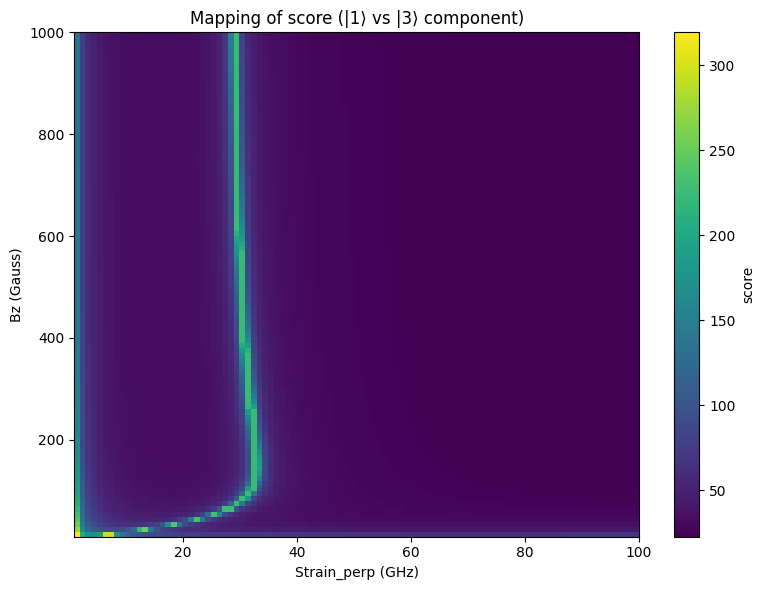

[[298.10161367 184.07113829 147.99075798 ...  43.4966549   43.36897891
   43.24210262]
 [262.12490774 150.93020819 114.34199871 ...  31.29309989  31.22798736
   31.16440134]
 [243.68758902 137.31376153 102.18956522 ...  28.38326707  28.36885568
   28.35811305]
 ...
 [143.38710048  85.6106543   66.6161231  ...  23.11492352  23.14913407
   23.18682516]
 [143.34601331  85.6030048   66.62022288 ...  23.11379184  23.14843476
   23.18655901]
 [143.30588521  85.59565199  66.62439341 ...  23.11276574  23.14783235
   23.18638099]]


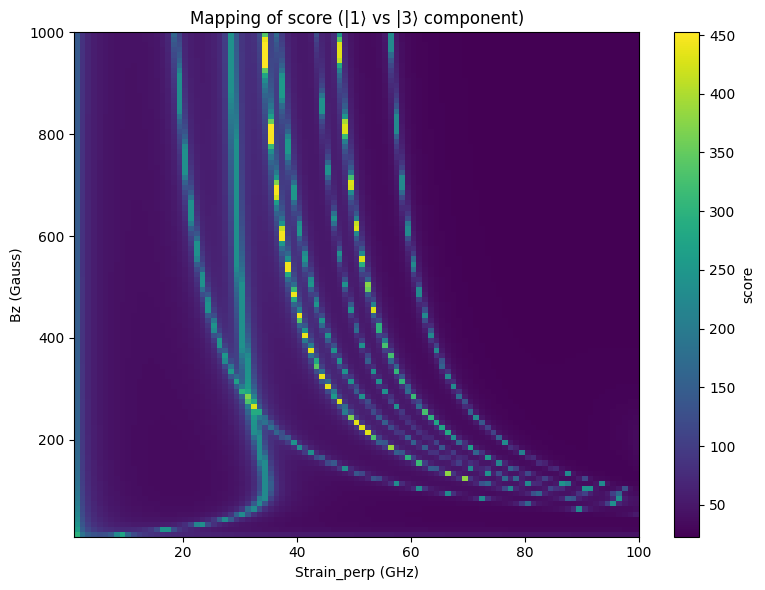

[[416.0179356  235.66500249 171.11280299 ...  35.32498341  35.26437479
   35.20717311]
 [426.3726696  319.90505698 221.76092031 ...  54.76199312  53.95985471
   53.26884783]
 [426.72523712 426.72847295 426.73388393 ... 255.32777564 285.0789402
  295.09150621]
 ...
 [187.63865648 104.87233225  77.49253273 ...  33.34050184  33.39430496
   33.47124855]
 [187.52082025 104.81677262  77.45764985 ...  33.34149886  33.39594283
   33.47347796]
 [187.40536732 104.76234845  77.42348839 ...  33.34249259  33.39756119
   33.47567276]]


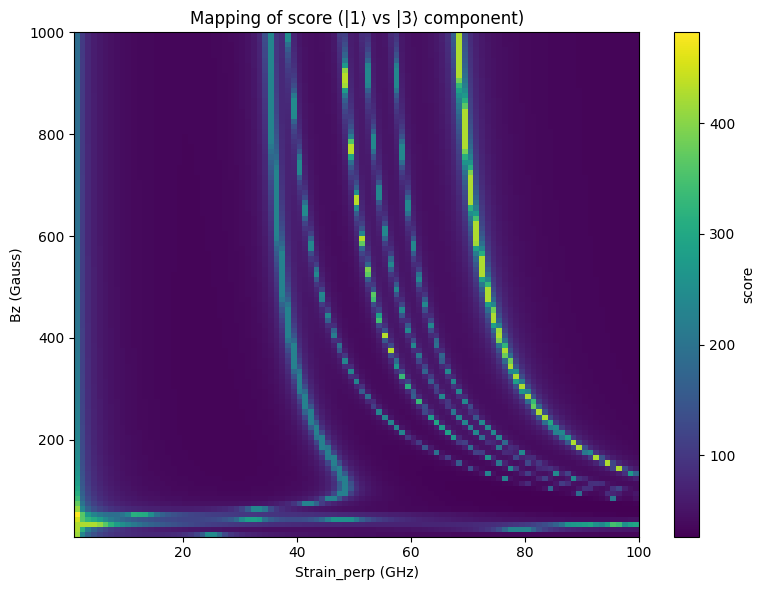

[[244.26976283 149.44476071 119.32211982 ...  78.90178769 101.84692622
  244.53131809]
 [188.06894209 112.07596955  87.26626    ...  32.86810042  33.0564383
   33.28379759]
 [150.0047134   90.51012013  71.06930857 ...  44.5365084   42.46994706
   41.12223364]
 ...
 [126.83851281  74.36488593  57.05548722 ...  24.4045959   24.39440608
   24.38465757]
 [126.89636344  74.39188187  57.07219601 ...  24.39949868  24.38926965
   24.37948295]
 [126.95307757  74.41835453  57.08858619 ...  24.39451959  24.38425206
   24.37442786]]


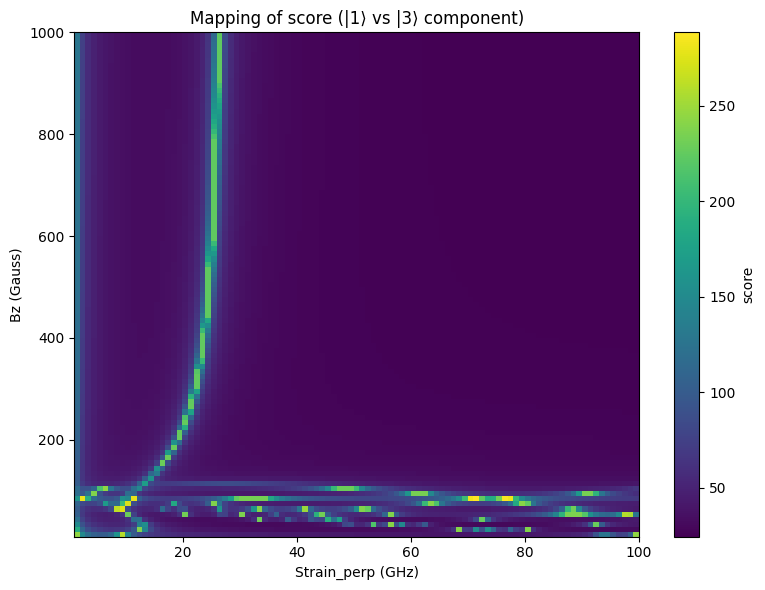

[[137.84484213  69.03912567  93.87011931 ... 107.55616257 260.45943112
   77.63969832]
 [ 48.64855529  45.04941392  49.77751144 ...  34.91963818  34.47409774
   34.09446788]
 [122.35127384  45.30795804  40.11131642 ...  29.55288905  29.54495599
   29.54221191]
 ...
 [129.73010748  76.59622709  59.11689309 ...  31.6768466   31.6503315
   31.62870891]
 [129.77767227  76.61415133  59.1246594  ...  31.67557439  31.64831859
   31.62599418]
 [129.82434942  76.63177694  59.13233143 ...  31.67444392  31.64645846
   31.6234429 ]]


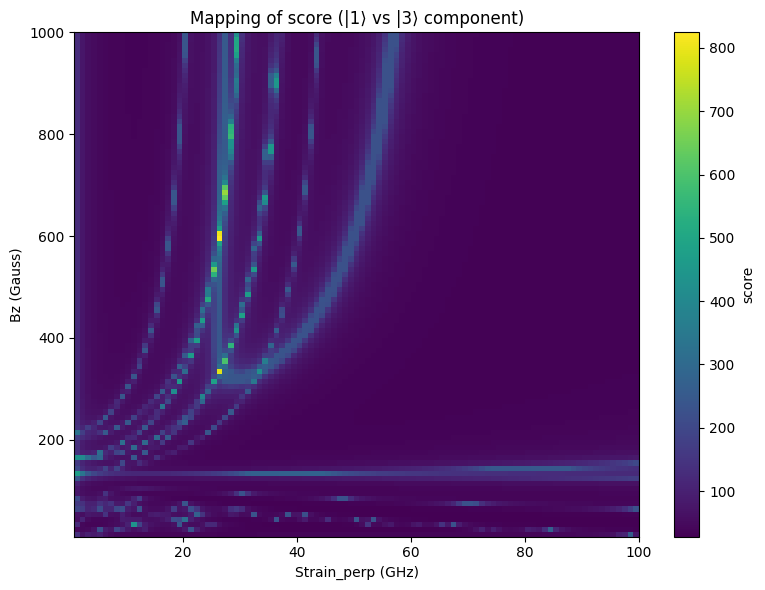

[[44.71002323 50.41940172 65.86957164 ... 49.35286444 49.48146221
  49.61009125]
 [41.13055162 34.07370569 33.00023754 ... 56.27090182 55.93774327
  55.62805072]
 [53.43413647 42.63973899 33.24047873 ... 54.8439293  54.93205606
  55.02681669]
 ...
 [99.78411286 60.70121837 47.84780759 ... 44.94229725 46.33929071
  47.91772891]
 [99.86878258 60.74165047 47.87338713 ... 44.94698274 46.34769459
  47.93087709]
 [99.95186899 60.78134215 47.89851044 ... 44.95141316 46.35575304
  47.94356935]]


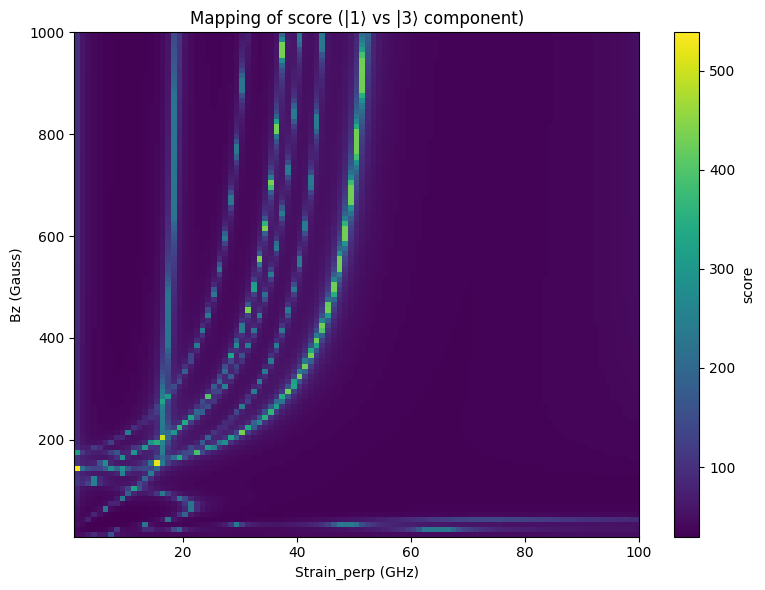

In [66]:
for spin_basis in range(6):
    map_spin_fun(spin_basis)

In [1]:
print("test")

test
